# Imports

In [1]:
!pip install numpy pandas matplotlib plotly scipy scikit-image scikit-learn torch torchvision kagglehub
!pip install nbformat

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.nn.functional as F
import kagglehub
import os

/Users/ameliamartinson/repos/540-project-code/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
pmem = True if device == "cuda" else False
print(device)

mps


In [4]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    ])
images = torchvision.datasets.ImageFolder("coil-20-proc", transform=transform)


train_size = int(0.8 * len(images))
valid_size = len(images) - train_size

images_train, images_valid = torch.utils.data.random_split(images, [train_size, valid_size])
print(images.classes)

train_images = DataLoader(images_train, batch_size=32, shuffle=True, pin_memory=pmem)
valid_images = DataLoader(images_valid, batch_size=32, shuffle=False,pin_memory=pmem)

['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


In [5]:
print(len(images_train))
len(images_valid)

1152


288

In [ ]:
def label_string(label_int):
    match label_int:
        case 0:
            return "duck"
        case 1:
            return "block toy"
        case 2:
            return "toy racecar"
        case 3:
            return "waving cat"
        case 4:
            return "anacin box"
        case 5:
            return "toy convertible"
        case 6:
            return "block toy 2"
        case 7:
            return "baby powder"
        case 8:
            return "tylenol"
        case 9:
            return "vaseline"
        case 10:
            return "block toy (semicircle)"
        case 11:
            return "cup"
        case 12:
            return "piggy bank"
        case 13:
            return "valve"
        case 14:
            return "bucket"
        case 15:
            return "conditioner bottle"
        case 16:
            return "pot"
        case 17:
            return "teacup"
        case 18:
            return "toy convertible (2)"
        case 19:
            return "cream cheese tub"
        case _:
            return "none of the above"

In [7]:
train_images

In [8]:
model = nn.Sequential()
model.add_module(
    'conv1',
    nn.Conv2d(
        in_channels=1,out_channels=32,
        kernel_size=5,padding=2
    )
)
model.add_module('relu1',nn.ReLU())
model.add_module('pool1',nn.MaxPool2d(kernel_size=2))

model.add_module(
    'conv2',
    nn.Conv2d(
        in_channels=32, out_channels=64,
        kernel_size=5,padding=2
    )
)
model.add_module('relu2',nn.ReLU())
model.add_module('pool2',nn.MaxPool2d(kernel_size=2))

model.add_module('avgpool',nn.AdaptiveAvgPool2d((4,4)))

model.add_module('flatten',nn.Flatten())

x = torch.ones((4,1,128,128))
dims = model(x).shape

model.add_module('fc1',nn.Linear(dims[1], 512))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout',nn.Dropout(p=0.5))
model.add_module('fc2',nn.Linear(512,20))
model.to(device)

Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=20, bias=True)
)

In [9]:
model_path = "prebuilts/coil20_0.000.pth"
model.load_state_dict(torch.load(model_path, weights_only=True, map_location=torch.device(device)))

<All keys matched successfully>

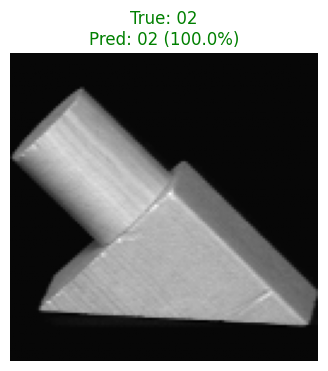

In [10]:
img_tensor, label = images[73]
input_tensor = img_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    probs = F.softmax(logits, dim=1)
    confidence, pred_label = torch.max(probs,1)

    predicted_class = images.classes[pred_label.item()]
    true_class = images.classes[label]
    conf_score = confidence.item()

    plt.figure(figsize=(4,4))
    plt.imshow(img_tensor.permute(1,2,0),cmap='gray')
    title_color = 'green' if predicted_class == true_class else 'red'
    plt.title(f"True: {true_class}\nPred: {predicted_class} ({conf_score:.1%})", color=title_color)
    plt.axis('off')
    plt.show()

In [21]:
def display_image_tensor(img_tensor):
    plt.figure(figsize=(4,4))
    plt.imshow(img_tensor.permute(1,2,0), cmap='gray')
    plt.axis('off')
    plt.show()

In [49]:
def display_image_tensor_withresults(img_tensor,true_int, pred_pert_int, conf_pert_float):
    plt.figure(figsize=(4,4))
    if true_int == pred_pert_int:
        my_color = 'green'
    else:
        my_color = 'red'
    plt.title(f"True: {label_string(true_int)}\nPred: {label_string(pred_pert_int)} ({conf_pert_float:.1%})", color=my_color)
    plt.imshow(img_tensor.permute(1,2,0), cmap='gray')
    plt.axis('off')
    plt.show()

In [50]:
def attack(image_index, delta, n):
    # Attack
    #perturbed_image_disp = perturbed_image.cpu().detach()
    #display_image_tensor(perturbed_image_disp)
    image_tensor, label = images[image_index]
    start_image = image_tensor.unsqueeze(0).to(device)
    label = torch.Tensor([label]).to(device)

    final_pred = -1
    conf_final = 0.0

    start_image.requires_grad = True
    for i in range(n):

        start_image.requires_grad = True

        output = model(start_image)
        init_pred = output.max(1, keepdim=True)[1]

        loss = F.nll_loss(output, label.long())
        model.zero_grad()
        loss.backward()

        image_grad = start_image.grad.data
        #grad_sign = torch.sign(image_grad)
        perturbed_image = start_image + delta*image_grad
        #perturbed_image = start_image + delta*grad_sign
        perturbed_image = torch.clamp(perturbed_image,0,1)

        output_pert = model(perturbed_image)

        pert_pred = output_pert.max(1,keepdim=True)[1]
        probs_init = F.softmax(output, dim=1)
        probs_pert = F.softmax(output_pert, dim=1)

        confidence_init, pred_label_init = torch.max(probs_init,1)
        conf_init_float = float(confidence_init.detach())
        pred_init_int = int(pred_label_init.detach())

        confidence_pert, pred_label_pert = torch.max(probs_pert,1)
        conf_pert_float = float(confidence_pert.detach())
        pred_pert_int = int(pred_label_pert.detach())
        #print("init_pred: {}, with confidence: {:f}".format(label_string(pred_init_int), conf_init_float))
        print("pred: {}, with confidence: {:f}".format(label_string(pred_pert_int), conf_pert_float))
        final_pred = pred_pert_int
        if i==0:
            conf_init = conf_pert_float
        conf_final = conf_pert_float
        if init_pred != pert_pred:
            break
        start_image = perturbed_image.detach()

    return_image = start_image.squeeze(0).cpu().detach()
    diff_image = torch.abs(return_image - image_tensor)

    return return_image, diff_image, final_pred, conf_init, conf_final

4
pred: anacin box, with confidence: 0.999997
pred: anacin box, with confidence: 0.968024
pred: toy convertible (lame), with confidence: 0.999987
tensor(6.0738)


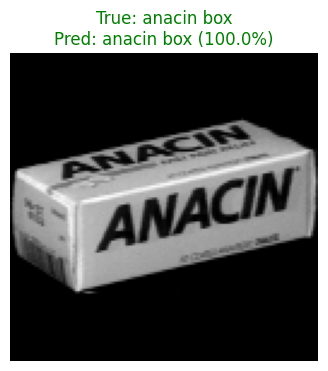

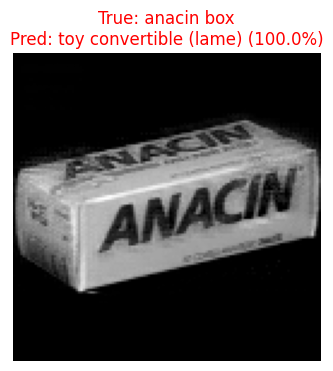

In [62]:
image_num = 350
true_val = image_num // 72
print(true_val)
image_attack, diff, final_pred, conf_init, conf_final = attack(image_num, 1,200)
print(torch.norm(diff))
image_original, _ = images[image_num]
#display_image_tensor(image_original)
#display_image_tensor(image_attack)
#display_image_tensor(diff)
display_image_tensor_withresults(image_original, true_val , true_val, conf_init )
display_image_tensor_withresults(image_attack, true_val, final_pred, conf_final )

In [14]:
#torch.save(model.state_dict(), "test.pth")

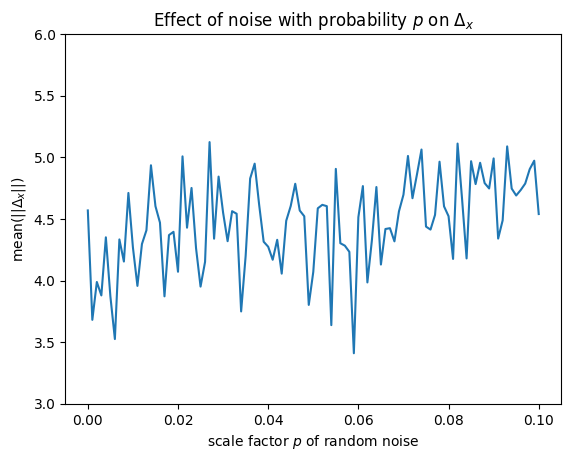

In [18]:
# These are the results of the NN in Coil20_simplified_small.ipynb
results = torch.load("results_small1.pk")
result = torch.tensor(results)
means = result.mean(dim=1)
#means = result
p_axis = np.linspace(0,0.1,101)
plt.plot(p_axis, means)
plt.xlabel(r"scale factor $p$ of random noise")
plt.ylabel(r"$\text{mean}(||\Delta_x||)$")
plt.ylim([3,6])
plt.title(r"Effect of noise with probability $p$ on $\Delta_x$")
plt.show()